# 01 — Feature Factory
**Purpose:** Load the full SP500 universe, engineer 40+ stationary cross-sectional features,
compute Rolling Rank IC, drop low-IC features, and save the clean feature matrix.

**Pipeline:**
1. Load all SP500 CSVs → panel DataFrame
2. Calculate log returns
3. Engineer features (grouped by Ticker, fully vectorized — no for-loops)
4. Compute forward targets (5-day cross-sectional rank)
5. Calculate Rolling Rank IC per feature
6. Drop features with mean |IC| < 0.02
7. Orthogonalize with PCA
8. Save to `features_panel.parquet`

**Reference:** roadmap_phase2.md — Phase 2: Alpha Factory

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import json
import pickle

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 60)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('../sp500')
OUTPUT_DIR = Path('.')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Global Parameters ─────────────────────────────────────────────────────────
MIN_YEARS        = 3          # minimum history per ticker
STUDY_START      = '2010-01-01'
STUDY_END        = '2022-12-31'
FORWARD_DAYS     = 5          # prediction horizon (trading days)
IC_MIN_THRESHOLD = 0.02       # drop features below this mean |Rank IC|
IC_ROLLING_WIN   = 126        # ~6 months rolling window for IC calculation
CLIP_PERCENTILE  = 99.9       # clip extreme outliers

print('✓ Imports and config loaded')

✓ Imports and config loaded


## 1 — Load SP500 Universe

In [2]:
def load_sp500_universe(data_dir: Path, min_years: int = 3) -> pd.DataFrame:
    """Load all SP500 CSVs, filter by history length, return a clean panel."""
    frames = []
    data_dir = Path(data_dir)
    skipped = []

    for csv_path in sorted(data_dir.glob('*.csv')):
        ticker = csv_path.stem
        try:
            df = pd.read_csv(
                csv_path,
                parse_dates=['Date'],
                index_col='Date'
            )
            df.index = pd.to_datetime(df.index)
            df = df.rename(columns={
                'Open': 'open', 'High': 'high', 'Low': 'low',
                'Close': 'close', 'Volume': 'volume'
            })
            df = df[['open', 'high', 'low', 'close', 'volume']].dropna()
            if len(df) < min_years * 252:
                skipped.append(ticker)
                continue
            df['ticker'] = ticker
            frames.append(df)
        except Exception as e:
            skipped.append(ticker)

    panel = pd.concat(frames)
    panel = panel.reset_index()
    panel = panel.rename(columns={'Date': 'date'})
    panel = panel.sort_values(['ticker', 'date']).reset_index(drop=True)

    # Filter to study window
    panel = panel[(panel['date'] >= STUDY_START) & (panel['date'] <= STUDY_END)]

    print(f'Loaded {panel["ticker"].nunique()} tickers  |  {len(panel):,} rows')
    print(f'Date range: {panel["date"].min().date()} → {panel["date"].max().date()}')
    print(f'Skipped (insufficient history): {len(skipped)} tickers')
    return panel


panel = load_sp500_universe(DATA_DIR, min_years=MIN_YEARS)
panel.head()

Loaded 499 tickers  |  1,515,729 rows
Date range: 2010-01-04 → 2022-07-12
Skipped (insufficient history): 4 tickers


,date,open,high,low,close,volume,ticker
2545,2010-01-04,20.425381,20.581549,20.256200,20.366819,3815561.0,A
2546,2010-01-05,20.308265,20.314771,20.015449,20.145590,4186031.0,A
2547,2010-01-06,20.074011,20.171615,20.015447,20.074011,3243779.0,A
2548,2010-01-07,20.028458,20.054488,19.846264,20.047981,3095172.0,A
2549,2010-01-08,19.937366,20.074013,19.781200,20.041477,3733918.0,A


In [3]:
# ── Compute log returns (vectorized, per ticker) ───────────────────────────────
panel = panel.sort_values(['ticker', 'date']).reset_index(drop=True)
panel['log_ret'] = (
    panel.groupby('ticker')['close']
         .transform(lambda s: np.log(s / s.shift(1)))
)

# Drop first row per ticker (NaN return)
panel = panel.dropna(subset=['log_ret']).reset_index(drop=True)
print(f'Panel after log_ret: {len(panel):,} rows, {panel["ticker"].nunique()} tickers')

Panel after log_ret: 1,515,230 rows, 499 tickers


## 2 — Feature Engineering (40+ Signals, No Look-Ahead Bias)

In [4]:
# All features are computed at time t then SHIFTED by 1 day so that no future
# data leaks into the feature vector used at time t.

def make_rolling(s, window, func='mean'):
    """Thin wrapper for rolling transforms."""
    r = s.rolling(window, min_periods=window // 2)
    return getattr(r, func)()


def compute_rsi(s, period=14):
    delta = s.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)
    avg_g = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_l = loss.ewm(com=period - 1, min_periods=period).mean()
    rs    = avg_g / avg_l.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_atr(h, l, c, period=14):
    prev_c = c.shift(1)
    tr = pd.concat([
        h - l,
        (h - prev_c).abs(),
        (l - prev_c).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(com=period - 1, min_periods=period).mean()


print('Helper functions defined ✓')

Helper functions defined ✓


In [5]:
%%time
# ─────────────────────────────────────────────────────────────────────────────
# Build all features per ticker using groupby + apply (vectorized within group)
# ─────────────────────────────────────────────────────────────────────────────

FEAT_COLS = []   # populated below

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all alpha features for a single ticker's time-series."""
    close  = df['close']
    high   = df['high']
    low    = df['low']
    vol    = df['volume'].replace(0, np.nan)
    ret    = df['log_ret']

    out = pd.DataFrame(index=df.index)

    # ── A. Momentum / Return Signals ─────────────────────────────────────────
    for n in [5, 10, 21, 63, 126, 252]:
        out[f'mom_{n}'] = close.pct_change(n)

    # ── B. Volatility Features ────────────────────────────────────────────────
    for n in [5, 10, 21, 63]:
        out[f'vol_{n}'] = ret.rolling(n, min_periods=n // 2).std() * np.sqrt(252)

    # Volatility ratios (short / long) → regime signal
    out['vol_ratio_5_21']  = out['vol_5']  / out['vol_21'].replace(0, np.nan)
    out['vol_ratio_10_63'] = out['vol_10'] / out['vol_63'].replace(0, np.nan)
    out['vol_ratio_21_63'] = out['vol_21'] / out['vol_63'].replace(0, np.nan)

    # ── C. Moving Average Features ────────────────────────────────────────────
    for n in [5, 10, 20, 50, 100, 200]:
        ma = close.rolling(n, min_periods=n // 2).mean()
        out[f'ma_ratio_{n}'] = close / ma.replace(0, np.nan) - 1  # price vs MA

    # EMA ratios
    ema12 = close.ewm(span=12, min_periods=8).mean()
    ema26 = close.ewm(span=26, min_periods=18).mean()
    ema9  = close.ewm(span=9,  min_periods=6).mean()
    macd        = ema12 - ema26
    macd_signal = macd.ewm(span=9, min_periods=6).mean()
    out['macd_norm']        = macd / close.replace(0, np.nan)
    out['macd_hist_norm']   = (macd - macd_signal) / close.replace(0, np.nan)

    # ── D. Bollinger Band Features ────────────────────────────────────────────
    bb_mid  = close.rolling(20, min_periods=10).mean()
    bb_std  = close.rolling(20, min_periods=10).std()
    bb_up   = bb_mid + 2 * bb_std
    bb_lo   = bb_mid - 2 * bb_std
    out['bb_width']    = (bb_up - bb_lo) / bb_mid.replace(0, np.nan)
    out['bb_position'] = (close - bb_lo) / (bb_up - bb_lo).replace(0, np.nan)
    out['bb_position'] = out['bb_position'].clip(0, 1)  # cap [0,1]

    # ── E. RSI ────────────────────────────────────────────────────────────────
    out['rsi_14']  = compute_rsi(close, 14) / 100 - 0.5   # centered at 0
    out['rsi_28']  = compute_rsi(close, 28) / 100 - 0.5

    # ── F. ATR (normalized) ────────────────────────────────────────────────────
    out['atr_norm_14'] = compute_atr(high, low, close, 14) / close.replace(0, np.nan)

    # ── G. Volume Features ────────────────────────────────────────────────────
    vol_ma20  = vol.rolling(20, min_periods=10).mean()
    vol_ma60  = vol.rolling(60, min_periods=30).mean()
    out['vol_ratio_v']  = vol / vol_ma20.replace(0, np.nan) - 1   # volume surge
    out['vol_ratio_v_slow'] = vol_ma20 / vol_ma60.replace(0, np.nan) - 1
    # OBV momentum
    obv  = (np.sign(ret) * vol).cumsum()
    out['obv_slope'] = obv.diff(10) / (vol_ma20 * 10).replace(0, np.nan)

    # ── H. Mean-Reversion (z-score of price relative to long-term MA) ─────────
    ma_252 = close.rolling(252, min_periods=126).mean()
    std_252 = close.rolling(252, min_periods=126).std()
    out['price_zscore_252'] = (close - ma_252) / std_252.replace(0, np.nan)

    ma_63 = close.rolling(63, min_periods=30).mean()
    std_63 = close.rolling(63, min_periods=30).std()
    out['price_zscore_63'] = (close - ma_63) / std_63.replace(0, np.nan)

    # ── I. High-Low Range (realized spread proxy) ─────────────────────────────
    out['hl_range_norm'] = (high - low) / close.replace(0, np.nan)

    # ── J. Return Autocorrelation (mean-reversion vs momentum) ───────────────
    out['ret_autocorr_5']  = ret.rolling(21, min_periods=10).apply(
        lambda x: x.autocorr(lag=5) if len(x) >= 10 else np.nan, raw=False
    )

    # ── K. Skewness and Kurtosis of returns (tail risk) ───────────────────────
    out['ret_skew_21']  = ret.rolling(21, min_periods=10).skew()
    out['ret_kurt_21']  = ret.rolling(21, min_periods=10).kurt()

    # ── CRITICAL: Shift ALL features by 1 day (no look-ahead bias) ───────────
    out = out.shift(1)

    return out


# Apply per-ticker feature engineering
feats = (
    panel.groupby('ticker', group_keys=False)
         .apply(engineer_features)
)

FEAT_COLS = feats.columns.tolist()
print(f'\n✓ Engineered {len(FEAT_COLS)} raw features')
print(feats.shape)


✓ Engineered 35 raw features
(1515230, 35)
CPU times: total: 2min 18s
Wall time: 2min 19s


In [6]:
# ── Cross-Sectional Features (computed ACROSS tickers on the same date) ───────
# These require the full panel at each date, so we compute them AFTER per-ticker
# features are already shifted.

# Merge features with panel
feats_df = feats.copy()
feats_df['date']   = panel['date'].values
feats_df['ticker'] = panel['ticker'].values
feats_df['close']  = panel['close'].values
feats_df['log_ret'] = panel['log_ret'].values

# Already-shifted per-ticker momentum
# Cross-sectional rank of momentum features within each date
for mom_col in ['mom_5', 'mom_10', 'mom_21', 'mom_63', 'mom_126']:
    xs_rank_col = f'xs_rank_{mom_col}'
    feats_df[xs_rank_col] = (
        feats_df.groupby('date')[mom_col]
                .rank(pct=True, method='average')  # percentile rank [0, 1]
    )

# Cross-sectional z-score of vol
for vol_col in ['vol_21', 'vol_63']:
    xs_z_col = f'xs_z_{vol_col}'
    group = feats_df.groupby('date')[vol_col]
    feats_df[xs_z_col] = (feats_df[vol_col] - group.transform('mean')) / group.transform('std').replace(0, np.nan)

# Market-demeaned momentum (stock return minus cross-section mean → idiosyncratic momentum)
for mom_col in ['mom_5', 'mom_21', 'mom_63']:
    mkt_dm_col = f'mkt_dm_{mom_col}'
    group = feats_df.groupby('date')[mom_col]
    feats_df[mkt_dm_col] = feats_df[mom_col] - group.transform('mean')

XS_FEAT_COLS = [c for c in feats_df.columns if c.startswith(('xs_', 'mkt_dm_'))]
FEAT_COLS = FEAT_COLS + XS_FEAT_COLS
print(f'Total features after cross-sectional: {len(FEAT_COLS)}')

Total features after cross-sectional: 45


## 3 — Forward Return Target (Cross-Sectional Rank)

In [7]:
# Forward 5-day log return (FUTURE value — must NOT appear in features)
# This is computed per ticker, then cross-sectionally ranked per date

fwd_ret_series = (
    panel.groupby('ticker')['log_ret']
         .transform(lambda s: s.rolling(FORWARD_DAYS).sum().shift(-FORWARD_DAYS))
)

feats_df['fwd_ret_5d'] = fwd_ret_series.values

# Cross-sectional rank within each date (z-score style → continuous target)
group = feats_df.groupby('date')['fwd_ret_5d']
feats_df['target_cs_rank'] = (
    (group.rank(pct=True, method='average') - 0.5) * 2  # scale to [-1, +1]
)

# Directional label (binary: 1 = top half, 0 = bottom half)
feats_df['target_direction'] = (feats_df['target_cs_rank'] > 0).astype(int)

# Decile label (1 = worst, 10 = best)
feats_df['target_decile'] = (
    feats_df.groupby('date')['fwd_ret_5d']
            .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)
)

print(f'Target defined: fwd_ret_5d, target_cs_rank, target_direction, target_decile')
print(feats_df[['fwd_ret_5d', 'target_cs_rank', 'target_direction', 'target_decile']].describe())

Target defined: fwd_ret_5d, target_cs_rank, target_direction, target_decile
         fwd_ret_5d  target_cs_rank  target_direction  target_decile
count  1.512735e+06    1.512735e+06      1.515230e+06   1.512735e+06
mean   2.534897e-03    2.079677e-03      4.997981e-01   5.498349e+00
std    4.347523e-02    5.773492e-01      5.000001e-01   2.876678e+00
min   -1.477675e+00   -9.959920e-01      0.000000e+00   1.000000e+00
25%   -1.679176e-02   -4.979757e-01      0.000000e+00   3.000000e+00
50%    3.894741e-03    2.036660e-03      0.000000e+00   5.000000e+00
75%    2.369541e-02    5.022422e-01      1.000000e+00   8.000000e+00
max    1.169766e+00    1.000000e+00      1.000000e+00   1.000000e+01


## 4 — Rolling Rank IC (Feature Utility Score)

In [8]:
%%time
# ─────────────────────────────────────────────────────────────────────────────
# For each feature, compute the Spearman cross-sectional IC at each date,
# then report the time-series mean and std of that IC.
#
# IC at date t = Spearman_corr(feature_t_across_tickers, fwd_ret_5d_t_across_tickers)
# ─────────────────────────────────────────────────────────────────────────────

def calc_daily_ic(df: pd.DataFrame, feat_cols: list, target_col: str = 'fwd_ret_5d') -> pd.DataFrame:
    """Calculate cross-sectional Spearman IC per date for each feature."""
    results = []
    dates = df['date'].unique()

    for dt in dates:
        slice_ = df[df['date'] == dt][feat_cols + [target_col]].dropna()
        if len(slice_) < 20:  # need at least 20 stocks per date
            continue
        row = {'date': dt}
        for feat in feat_cols:
            if slice_[feat].std() < 1e-10:
                row[feat] = np.nan
                continue
            r, _ = spearmanr(slice_[feat], slice_[target_col])
            row[feat] = r
        results.append(row)

    ic_df = pd.DataFrame(results).set_index('date')
    return ic_df


# Run IC — this takes a few minutes on 500 stocks × 13 years
print('Computing daily cross-sectional Rank IC (this may take a few minutes)...')
ic_daily = calc_daily_ic(feats_df, FEAT_COLS)
print(f'IC matrix shape: {ic_daily.shape}')

# Summary statistics
ic_summary = pd.DataFrame({
    'mean_IC':     ic_daily.mean(),
    'mean_abs_IC': ic_daily.abs().mean(),
    'IC_IR':       ic_daily.mean() / ic_daily.std().replace(0, np.nan),  # IC Information Ratio
    'frac_pos':    (ic_daily > 0).mean()
}).sort_values('mean_abs_IC', ascending=False)

print('\n── Top 20 Features by mean |IC| ──')
print(ic_summary.head(20).to_string())

Computing daily cross-sectional Rank IC (this may take a few minutes)...
IC matrix shape: (2893, 45)

── Top 20 Features by mean |IC| ──
                   mean_IC  mean_abs_IC     IC_IR  frac_pos
atr_norm_14       0.006752     0.198424  0.026978  0.518493
vol_63            0.004807     0.196016  0.019564  0.513654
xs_z_vol_63       0.004807     0.196016  0.019564  0.513654
vol_21            0.003680     0.178305  0.016282  0.507777
xs_z_vol_21       0.003680     0.178305  0.016282  0.507777
mom_252           0.008626     0.177930  0.038437  0.531974
ma_ratio_200      0.001531     0.170479  0.006993  0.531282
mom_126           0.004195     0.167919  0.019390  0.552368
xs_rank_mom_126   0.004195     0.167919  0.019390  0.552368
price_zscore_252  0.001603     0.165793  0.007566  0.517802
vol_10            0.005575     0.161352  0.026792  0.519876
ma_ratio_100     -0.003968     0.153681 -0.019884  0.515036
rsi_28           -0.008628     0.146949 -0.045540  0.491186
mkt_dm_mom_63    -0.003

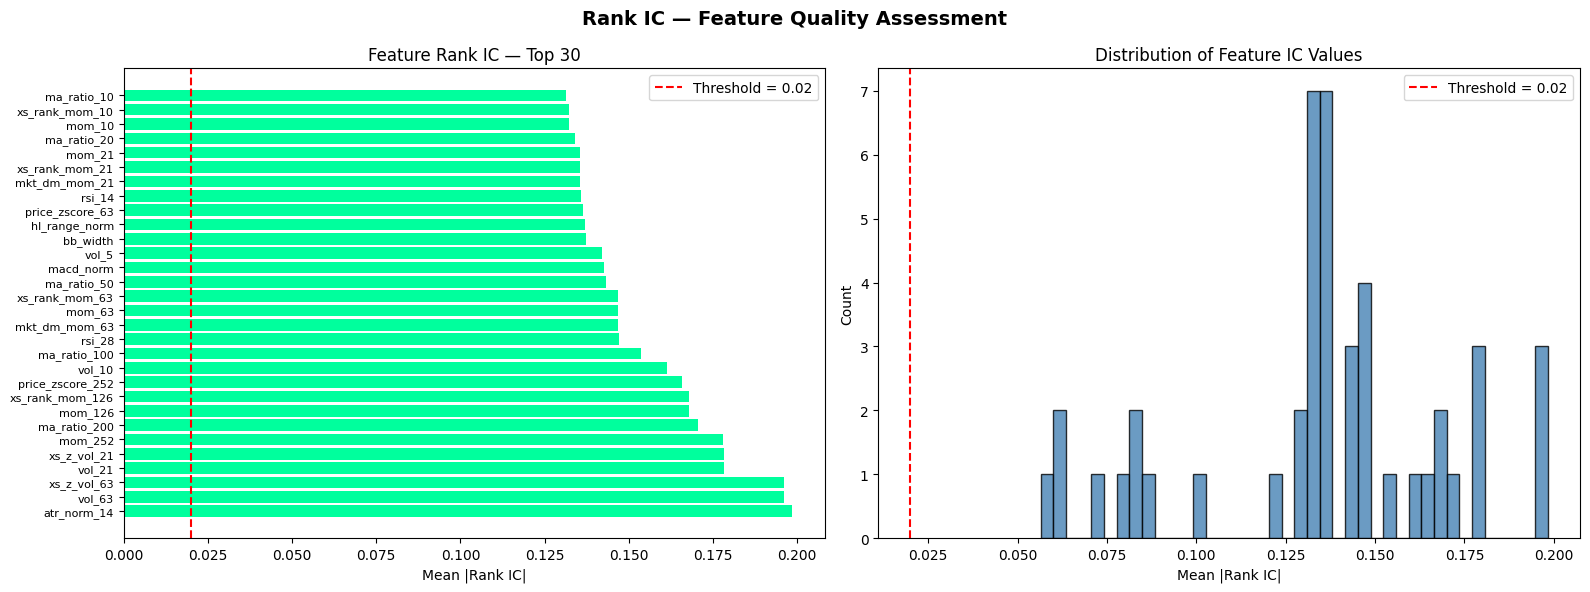

In [9]:
# ── IC Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar: mean |IC| per feature (top 30)
top30 = ic_summary.head(30)
axes[0].barh(
    range(len(top30)), top30['mean_abs_IC'].values,
    color=[
        '#00ff9d' if v >= IC_MIN_THRESHOLD else '#555'
        for v in top30['mean_abs_IC'].values
    ]
)
axes[0].set_yticks(range(len(top30)))
axes[0].set_yticklabels(top30.index, fontsize=8)
axes[0].axvline(IC_MIN_THRESHOLD, color='red', linestyle='--', label=f'Threshold = {IC_MIN_THRESHOLD}')
axes[0].set_xlabel('Mean |Rank IC|')
axes[0].set_title('Feature Rank IC — Top 30')
axes[0].legend()

# Distribution of all ICs
axes[1].hist(ic_summary['mean_abs_IC'].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(IC_MIN_THRESHOLD, color='red', linestyle='--', label=f'Threshold = {IC_MIN_THRESHOLD}')
axes[1].set_xlabel('Mean |Rank IC|')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Feature IC Values')
axes[1].legend()

plt.suptitle('Rank IC — Feature Quality Assessment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Feature Selection & Orthogonalization

In [10]:
# ── Filter: keep features with mean |IC| >= threshold ─────────────────────────
selected_feats = ic_summary[ic_summary['mean_abs_IC'] >= IC_MIN_THRESHOLD].index.tolist()
dropped_feats  = [f for f in FEAT_COLS if f not in selected_feats]

print(f'Selected features: {len(selected_feats)}')
print(f'Dropped features:  {len(dropped_feats)}')
print('\nSelected:')
for i, f in enumerate(selected_feats, 1):
    ic_val = ic_summary.loc[f, 'mean_abs_IC']
    ir_val = ic_summary.loc[f, 'IC_IR']
    print(f'  {i:3d}. {f:<35}  |IC|={ic_val:.4f}  IC-IR={ir_val:.3f}')

Selected features: 45
Dropped features:  0

Selected:
    1. atr_norm_14                          |IC|=0.1984  IC-IR=0.027
    2. vol_63                               |IC|=0.1960  IC-IR=0.020
    3. xs_z_vol_63                          |IC|=0.1960  IC-IR=0.020
    4. vol_21                               |IC|=0.1783  IC-IR=0.016
    5. xs_z_vol_21                          |IC|=0.1783  IC-IR=0.016
    6. mom_252                              |IC|=0.1779  IC-IR=0.038
    7. ma_ratio_200                         |IC|=0.1705  IC-IR=0.007
    8. mom_126                              |IC|=0.1679  IC-IR=0.019
    9. xs_rank_mom_126                      |IC|=0.1679  IC-IR=0.019
   10. price_zscore_252                     |IC|=0.1658  IC-IR=0.008
   11. vol_10                               |IC|=0.1614  IC-IR=0.027
   12. ma_ratio_100                         |IC|=0.1537  IC-IR=-0.020
   13. rsi_28                               |IC|=0.1469  IC-IR=-0.046
   14. mkt_dm_mom_63                        |IC

In [11]:
# ── Outlier Clipping (per feature, within each date cross-section) ─────────────
# Clip at [1 - p, p] percentile within each date to prevent extreme values
# from dominating tree splits or distance metrics.

print('Clipping outliers...')
for feat in selected_feats:
    lo  = feats_df.groupby('date')[feat].transform(lambda x: x.quantile(1 - CLIP_PERCENTILE / 100))
    hi  = feats_df.groupby('date')[feat].transform(lambda x: x.quantile(CLIP_PERCENTILE / 100))
    feats_df[feat] = feats_df[feat].clip(lo, hi)

print('✓ Outlier clipping complete')

Clipping outliers...
✓ Outlier clipping complete


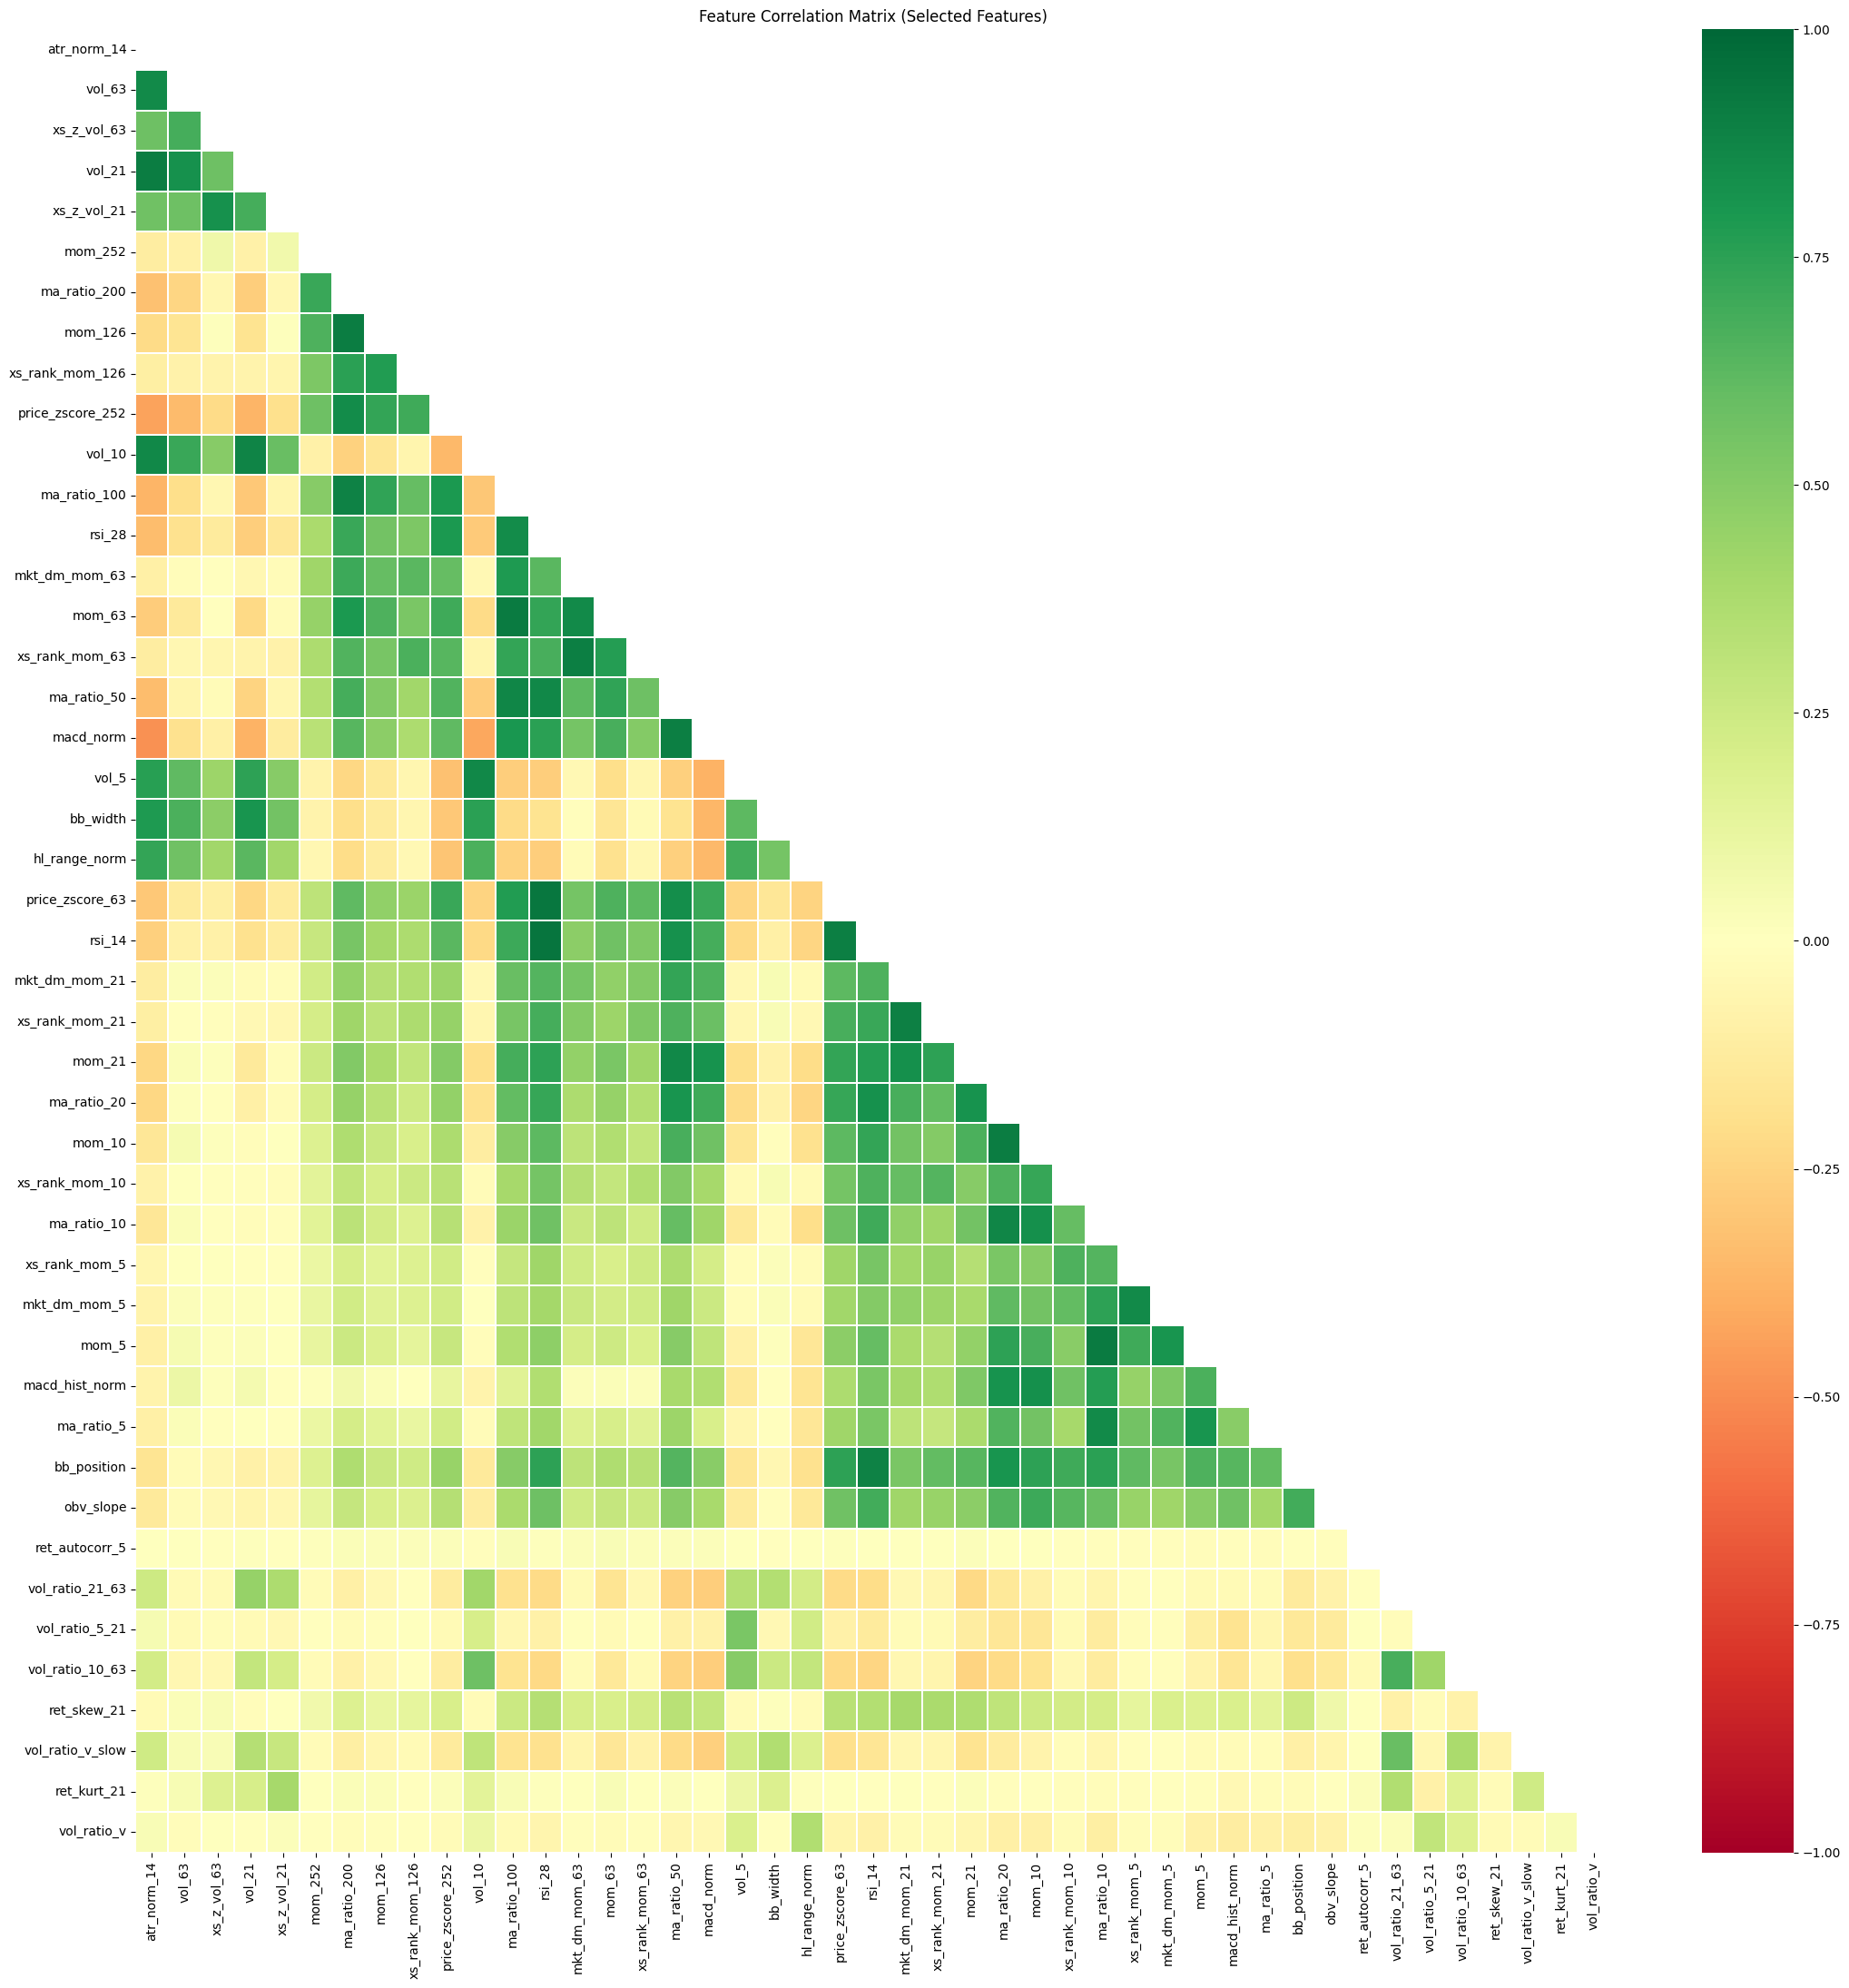


Highly correlated pairs (|r| > 0.85): 25
  rsi_28                              × rsi_14                              = 0.942
  rsi_28                              × price_zscore_63                     = 0.934
  ma_ratio_10                         × mom_5                               = 0.919
  ma_ratio_100                        × mom_63                              = 0.917
  ma_ratio_200                        × mom_126                             = 0.913
  atr_norm_14                         × vol_21                              = 0.912
  ma_ratio_20                         × mom_10                              = 0.910
  price_zscore_63                     × rsi_14                              = 0.905
  mkt_dm_mom_63                       × xs_rank_mom_63                      = 0.904
  ma_ratio_50                         × macd_norm                           = 0.904
  mkt_dm_mom_21                       × xs_rank_mom_21                      = 0.896
  rsi_14                          

In [12]:
# ── Correlation Matrix of Selected Features ───────────────────────────────────
# Check for multicollinearity before PCA orthogonalization

feat_data = feats_df[selected_feats].dropna()
corr_matrix = feat_data.corr()

fig, ax = plt.subplots(figsize=(max(10, len(selected_feats) // 2), max(8, len(selected_feats) // 2)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdYlGn', vmin=-1, vmax=1,
    center=0, linewidths=0.3, annot=False, ax=ax
)
ax.set_title('Feature Correlation Matrix (Selected Features)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Report highly correlated pairs
high_corr = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        c = abs(corr_matrix.iloc[i, j])
        if c > 0.85:
            high_corr.append((corr_matrix.index[i], corr_matrix.columns[j], c))

print(f'\nHighly correlated pairs (|r| > 0.85): {len(high_corr)}')
for a, b, c in sorted(high_corr, key=lambda x: -x[2])[:15]:
    print(f'  {a:35s} × {b:35s} = {c:.3f}')

PCA components to explain 95% variance: 20 / 45


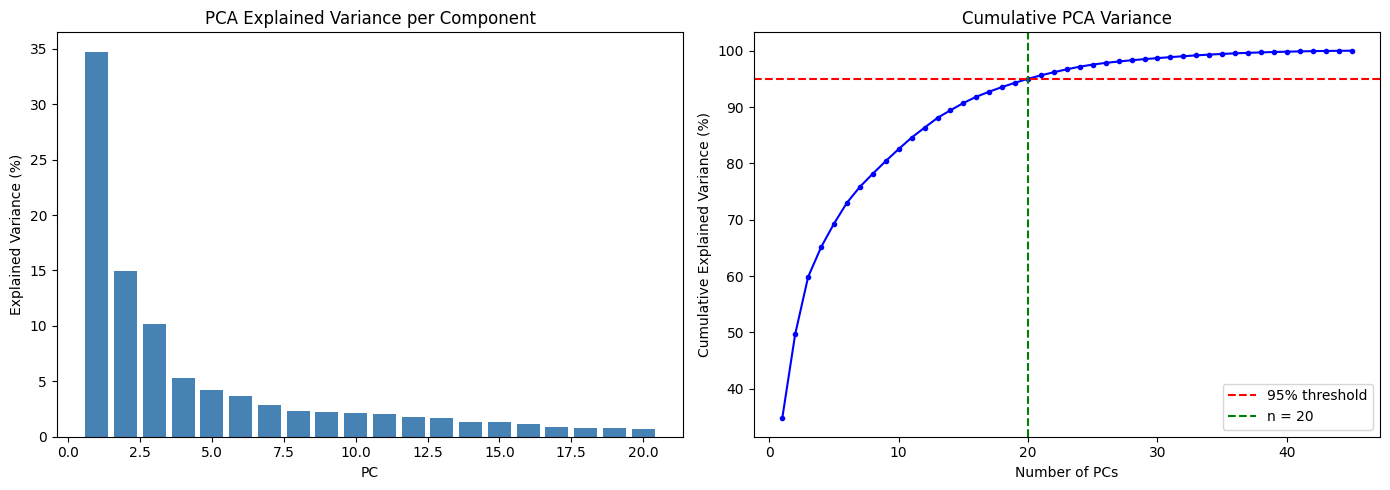

In [13]:
# ── PCA Orthogonalization ─────────────────────────────────────────────────────
# Transform correlated features into orthogonal PCA components.
# We keep enough components to explain ≥ 95% of variance.

clean_mask = feats_df[selected_feats].notna().all(axis=1)
X_raw = feats_df.loc[clean_mask, selected_feats].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Determine n_components for 95% explained variance
pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cum_var, 0.95)) + 1
print(f'PCA components to explain 95% variance: {n_components} / {len(selected_feats)}')

# Fit final PCA
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create PCA feature names
pca_cols = [f'pc_{i+1}' for i in range(n_components)]

# Explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Explained Variance per Component')

axes[1].plot(range(1, len(cum_var) + 1), cum_var * 100, 'bo-', markersize=3)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_components, color='green', linestyle='--', label=f'n = {n_components}')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative PCA Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Assemble Final Feature Panel

In [14]:
# ── Build the final DataFrame with:
#    - raw selected features (for tree models — trees don't need orthogonality)
#    - PCA-orthogonalized features (for distance-based methods: HRP clustering)
#    - target columns
#    - metadata

# Start with the full index
final_df = feats_df[['date', 'ticker', 'close', 'log_ret'] + selected_feats +
                    ['fwd_ret_5d', 'target_cs_rank', 'target_direction', 'target_decile']].copy()

# Add PCA features (only for rows with complete data)
pca_df = pd.DataFrame(
    np.nan, index=feats_df.index, columns=pca_cols
)
pca_df.loc[clean_mask, pca_cols] = X_pca
final_df = pd.concat([final_df, pca_df], axis=1)

# Remove rows where target is NaN (last FORWARD_DAYS rows per ticker)
final_df = final_df.dropna(subset=['target_cs_rank'])

print(f'Final panel shape: {final_df.shape}')
print(f'Tickers: {final_df["ticker"].nunique()}')
print(f'Dates:   {final_df["date"].nunique()}')
print(f'Features (raw selected): {len(selected_feats)}')
print(f'Features (PCA):          {n_components}')
final_df.tail()

Final panel shape: (1512735, 73)
Tickers: 499
Dates:   3146
Features (raw selected): 45
Features (PCA):          20


,date,ticker,close,log_ret,atr_norm_14,vol_63,xs_z_vol_63,vol_21,xs_z_vol_21,mom_252,ma_ratio_200,mom_126,xs_rank_mom_126,price_zscore_252,vol_10,ma_ratio_100,rsi_28,mkt_dm_mom_63,mom_63,xs_rank_mom_63,ma_ratio_50,macd_norm,vol_5,bb_width,hl_range_norm,price_zscore_63,rsi_14,mkt_dm_mom_21,xs_rank_mom_21,mom_21,...,vol_ratio_5_21,vol_ratio_10_63,ret_skew_21,vol_ratio_v_slow,ret_kurt_21,vol_ratio_v,fwd_ret_5d,target_cs_rank,target_direction,target_decile,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13,pc_14,pc_15,pc_16,pc_17,pc_18,pc_19,pc_20
1515220,2022-06-28,ZTS,170.119995,-0.020250,0.026415,0.315600,-0.575377,0.353510,-0.382799,-0.067393,-0.118743,-0.281748,0.218437,-1.258598,0.309593,-0.041812,0.011554,0.038812,-0.081962,0.629259,0.023782,-0.001484,0.240033,0.152579,0.013134,-0.035423,0.089561,0.098810,0.925852,0.064835,...,0.678999,0.980964,-0.202575,-0.097613,-1.112699,-0.315603,0.048085,0.879760,1,10.0,1.888425,2.431787,4.464946,0.454303,0.698411,0.646942,-1.634015,-0.531774,-0.245681,-0.194352,-0.347918,-0.046477,-1.440010,-0.483123,0.332344,-0.901565,0.733352,1.261030,0.194628,-0.051103
1515221,2022-06-29,ZTS,173.919998,0.022091,0.026986,0.317843,-0.565146,0.358173,-0.308595,-0.085356,-0.135620,-0.307567,0.204409,-1.432426,0.258815,-0.059374,-0.010638,0.035419,-0.100080,0.619238,0.005257,0.000303,0.358124,0.150767,0.027392,-0.308528,0.039640,0.094764,0.933868,0.025437,...,0.999863,0.814284,-0.005295,-0.099667,-1.223848,-0.136310,0.029349,0.378758,1,7.0,0.573385,2.223886,3.599678,0.024114,1.713511,1.183289,-1.440560,0.190568,-0.206342,-0.476193,0.280892,-0.348319,-1.605665,-1.126550,-0.119761,-0.219948,0.868556,0.677676,0.002317,0.357271
1515222,2022-06-30,ZTS,171.889999,-0.011741,0.026577,0.319613,-0.536176,0.343201,-0.344529,-0.069452,-0.115635,-0.285550,0.260521,-1.228756,0.267329,-0.036944,0.013272,0.059569,-0.093902,0.681363,0.028754,0.003429,0.368802,0.154255,0.028749,0.042710,0.081328,0.105932,0.939880,0.010575,...,1.074592,0.836415,-0.094017,-0.157371,-1.253230,-0.112263,0.034816,0.462926,1,8.0,1.644260,2.543207,3.792238,0.176699,1.981719,0.647984,-1.336450,0.031500,-0.243581,-0.647805,0.038196,-0.378470,-1.474829,-1.045468,0.033495,-0.299468,0.810822,0.696600,-0.053160,0.401977
1515223,2022-07-01,ZTS,174.210007,0.013407,0.026670,0.320191,-0.532521,0.344942,-0.329794,-0.072269,-0.125274,-0.301836,0.246493,-1.327905,0.286466,-0.046744,0.000294,0.053297,-0.099985,0.661323,0.018400,0.004971,0.356777,0.156793,0.021642,-0.110570,0.052543,0.098665,0.901804,0.005616,...,1.034307,0.894670,-0.064622,-0.143918,-1.296838,0.173716,0.016114,0.470942,1,8.0,0.458302,1.830269,2.915114,-0.252464,2.053071,1.488830,-1.109611,0.462249,-0.468644,-0.548798,0.152863,-0.032084,-1.503687,-1.249388,-0.013081,-0.367110,0.706044,0.959393,-0.349638,-0.249318
1515224,2022-07-05,ZTS,174.250000,0.000230,0.026075,0.320533,-0.534951,0.336832,-0.417013,-0.074301,-0.112817,-0.287015,0.256513,-1.201821,0.278172,-0.032496,0.014833,0.056130,-0.074633,0.661323,0.033808,0.007072,0.280430,0.158679,0.022961,0.118163,0.078246,0.114627,0.931864,0.043049,...,0.832551,0.867842,-0.254691,-0.138043,-1.118542,-0.210100,-0.002528,-0.022044,0,5.0,1.239370,1.766848,3.132590,-0.619105,1.402012,1.700648,-1.477151,0.641340,-0.497538,-0.433103,-0.277093,-0.134786,-1.561580,-0.905892,0.116689,-0.524199,0.793563,1.107262,0.130227,0.272116


In [15]:
# ── Save ──────────────────────────────────────────────────────────────────────

# Main feature panel
final_df.to_parquet(OUTPUT_DIR / 'features_panel.parquet', index=False)

# IC summary (for reference and model monitoring)
ic_summary.to_csv(OUTPUT_DIR / 'feature_ic_summary.csv')

# Feature metadata (for downstream notebooks)
feature_meta = {
    'selected_features': selected_feats,
    'pca_cols':          pca_cols,
    'n_pca_components':  n_components,
    'forward_days':      FORWARD_DAYS,
    'study_start':       STUDY_START,
    'study_end':         STUDY_END,
    'ic_threshold':      IC_MIN_THRESHOLD,
    'scaler_type':       'StandardScaler',
}
with open(OUTPUT_DIR / 'feature_meta.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)

# Save fitted scaler and PCA for deployment
with open(OUTPUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(OUTPUT_DIR / 'pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print('✓ Saved:')
print('  features_panel.parquet')
print('  feature_ic_summary.csv')
print('  feature_meta.json')
print('  scaler.pkl')
print('  pca.pkl')

✓ Saved:
  features_panel.parquet
  feature_ic_summary.csv
  feature_meta.json
  scaler.pkl
  pca.pkl


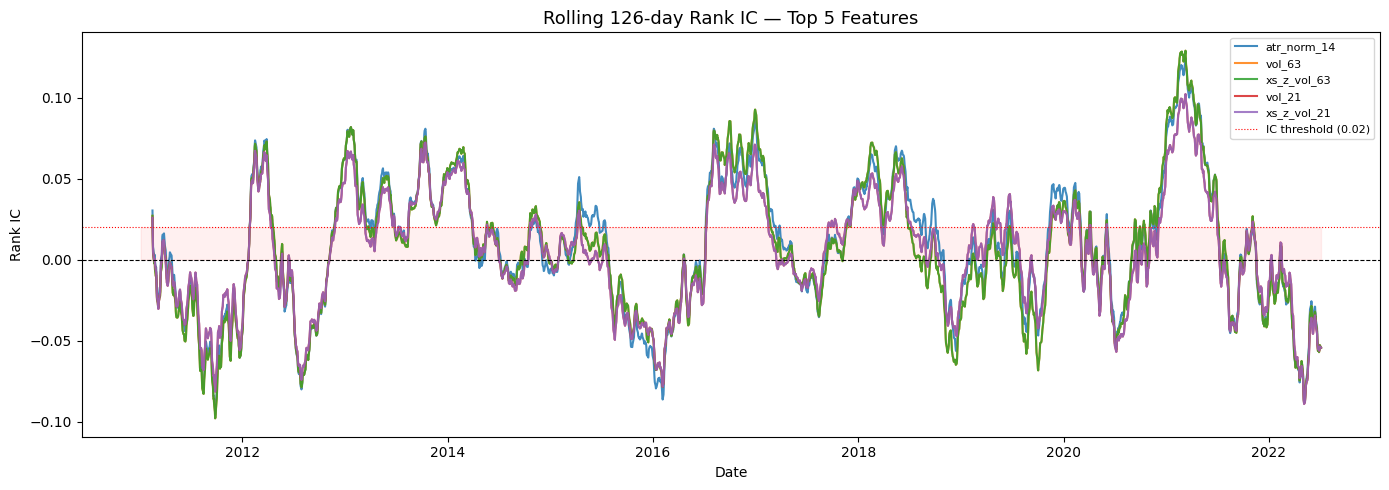


── Feature Factory Complete ──
  45 features selected | 20 PCA components
  Panel: 1,512,735 rows  |  499 tickers


In [16]:
# ── Rolling IC Decay Plot (top 5 features) ────────────────────────────────────
top5 = ic_summary.head(5).index.tolist()
rolling_ic = ic_daily[top5].rolling(IC_ROLLING_WIN, min_periods=30).mean()

fig, ax = plt.subplots(figsize=(14, 5))
for feat in top5:
    ax.plot(rolling_ic.index, rolling_ic[feat], label=feat, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(IC_MIN_THRESHOLD, color='red', linewidth=0.8, linestyle=':', label=f'IC threshold ({IC_MIN_THRESHOLD})')
ax.fill_between(rolling_ic.index, 0, IC_MIN_THRESHOLD, alpha=0.06, color='red')
ax.set_title(f'Rolling {IC_ROLLING_WIN}-day Rank IC — Top 5 Features', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Rank IC')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rolling_ic_top5.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Feature Factory Complete ──')
print(f'  {len(selected_feats)} features selected | {n_components} PCA components')
print(f'  Panel: {len(final_df):,} rows  |  {final_df["ticker"].nunique()} tickers')